In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("netflix.csv")

# Basic info
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


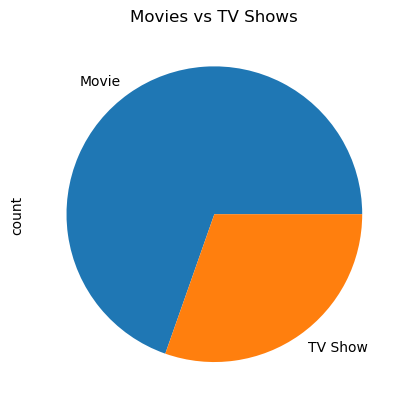

In [3]:
#Q1. What is the ratio of Moives vs TV Shows on Netflix?
type_counts = df['type'].value_counts()
print(type_counts)

type_counts.plot(kind='pie')
plt.title("Movies vs TV Shows")
plt.show()

In [ ]:
#INSIGHT
.Movies are more than TV Shows
. TV Shows are increasing gradually

 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     774
 Independent Movies        736
 TV Dramas                 696
 Romantic Movies           613
Name: count, dtype: int64


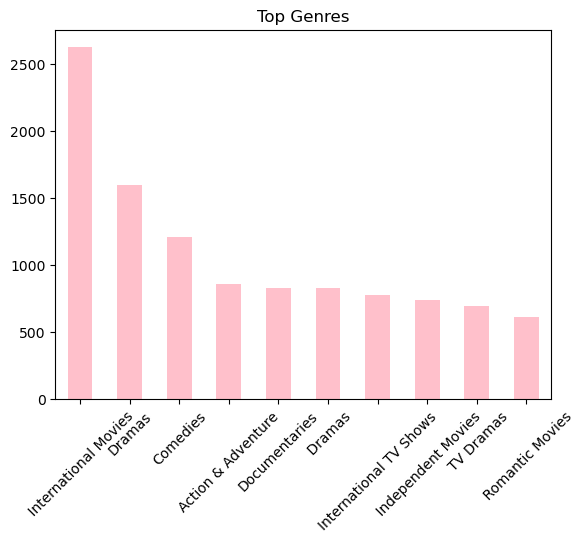

In [4]:
#Q2.Which geners are most popular on Netflix globally?
genres = df['listed_in'].str.split(',', expand=True).stack()
top_genres = genres.value_counts().head(10)

print(top_genres)

top_genres.plot(kind='bar', color='pink')
plt.title("Top Genres")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#INSHIGHT
. Dram is the most popular genre
. Comedy is also highly preferred
.International content is growing fast

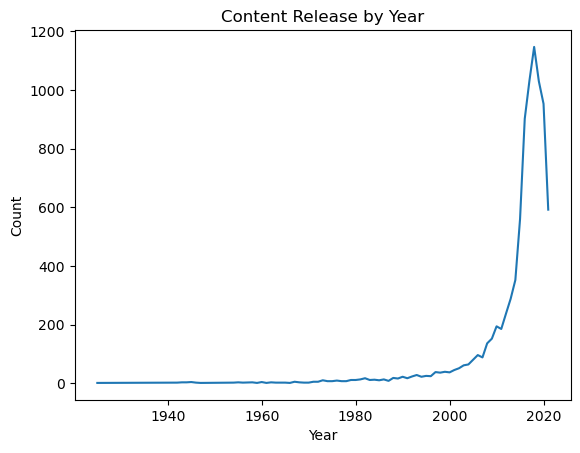

In [5]:
#Q3. Which years saw the highest release os content on Netflix?
release_year = df['release_year'].value_counts().sort_index()

release_year.plot()
plt.title("Content Release by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [ ]:
#INSHIGHT
. Highest releases in 2018-2020
. Netflix expanded rapidly in these years

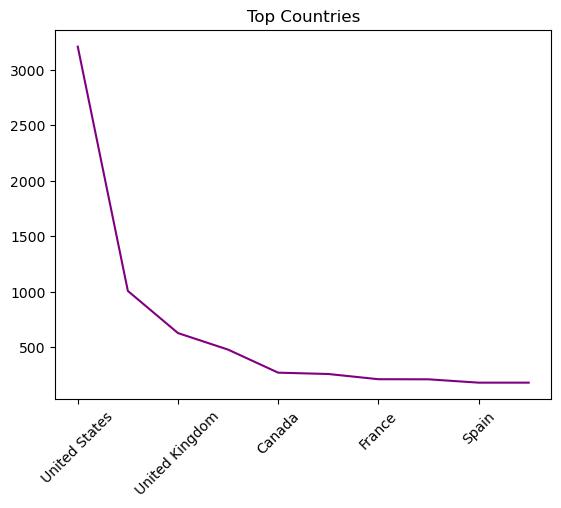

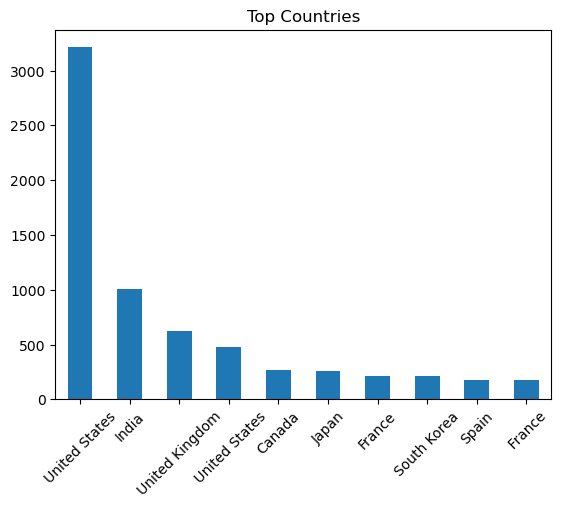

In [7]:
countries = df['country'].str.split(',', expand=True).stack()
top_countries = countries.value_counts().head(10)

top_countries.plot(kind='line', color='purple')
plt.title("Top Countries")
plt.xticks(rotation=45)
plt.show()#Q4.Whichbcountries produce the most Netflix content?
countries = df['country'].str.split(',', expand=True).stack()
top_countries = countries.value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top Countries")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#INSHIGHT
.USA produces most content
.India and UK are also major contributors


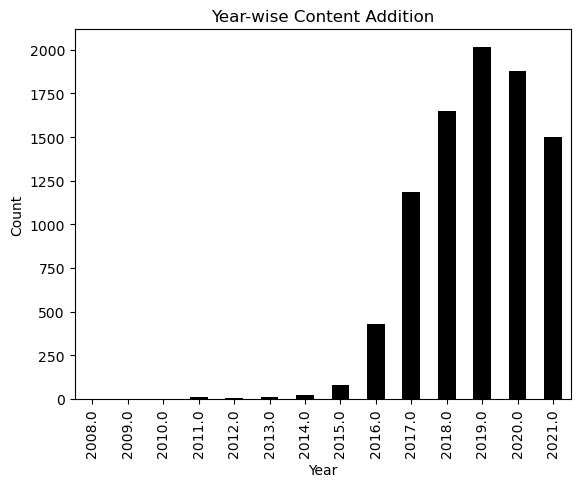

In [13]:
#Q5. How  has the trend pf adding new content evolved year by year?
# Convert to datetime (fix error)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Drop missing values
year_data = df['date_added'].dt.year.dropna()

# Plot
year_data.value_counts().sort_index().plot(kind='bar', color='k')
plt.title("Year-wise Content Addition")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [ ]:
#INSGHIT
.Content addition increased after 2015
. Rapid growth till 2020

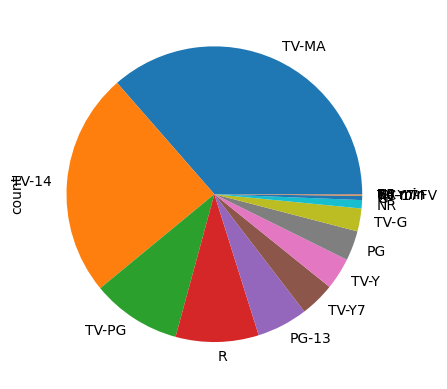

In [14]:
#Q6. Whichbrating are most frequently on Netflix?
df['rating'].value_counts().plot(kind='pie')
plt.show()

In [ ]:
#INSGHIT
.TV-MA rating is most common
.Content mainly targets adults and teens

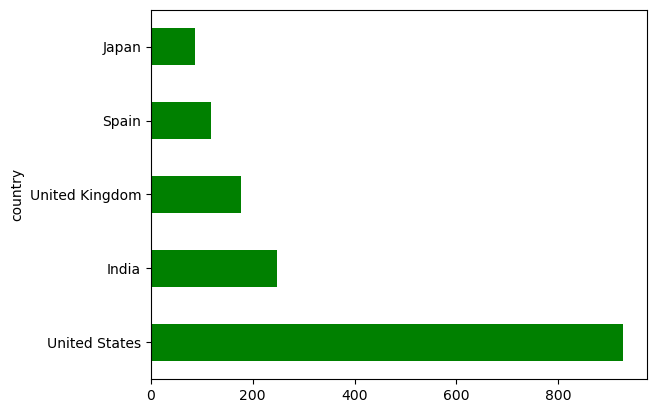

In [16]:
#Q7.Do some countries tend to produce more mature content (TV-MA)?
df[df['rating']=='TV-MA']['country'].value_counts().head().plot(kind='barh', color='green')
plt.show()

In [ ]:
#INSGHIT
.USA produces most mature content
.Mature content dominates platform

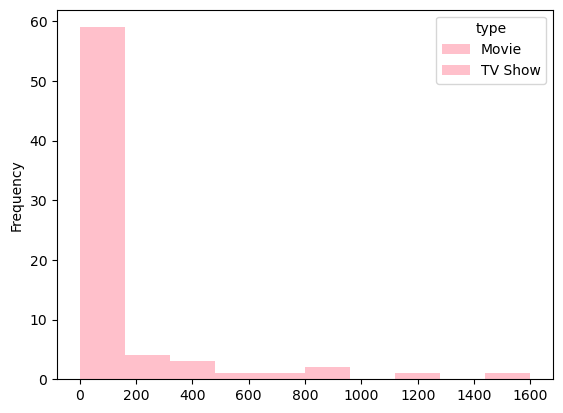

In [17]:
#Q8. Which geners are more associated with TV shows vs Movies?
df['genre']=df['listed_in'].apply(lambda x:x.split(',')[0])
pd.crosstab(df['genre'],df['type']).plot(kind='hist', color='pink' ,stacked=True)
plt.show()

In [ ]:
#INSGHIT
.TV shows mainly focus on Drama
.Movies have mixed geners

In [18]:
#Q9. Which geners dominate the U.S. vs other countries?
df[df['country'].str.contains('United States',na=False)]['genre'].value_counts().head()

genre
Dramas                      547
Documentaries               488
Comedies                    406
Action & Adventure          404
Children & Family Movies    368
Name: count, dtype: int64

In [ ]:
#INSGHIT
.US content- Drama and Action 
.Other countries- Regional and diverse geners

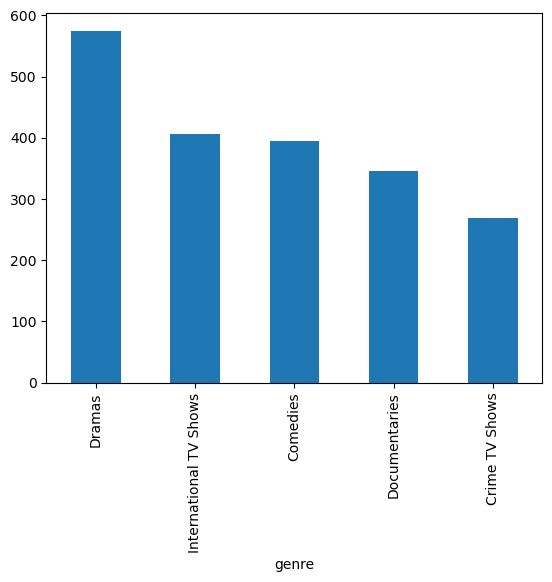

In [20]:
#10. What geners are most popular in the last 3 years?
df[df['release_year']>=2018]['genre'].value_counts().head().plot(kind='bar')
plt.show()

In [ ]:
#INSGHIT
.Thriller and Crime genres are rising
.Audience prefers realstic content

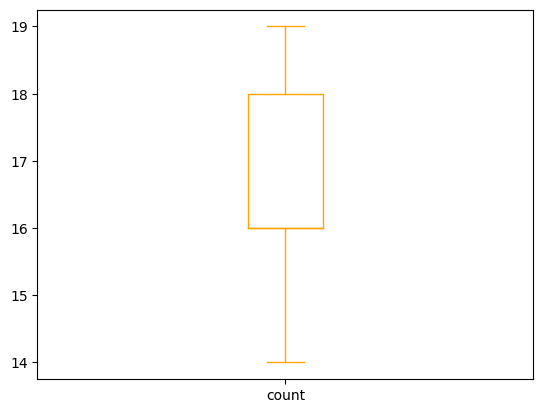

In [22]:
#Q11. Who are the top 10 director with the most Netflix content?
df['director'].value_counts().head().plot(kind='box', color='orange')
plt.show()

In [ ]:
#INSGHIT
.Few directors create most content
.Strong partnerships exist

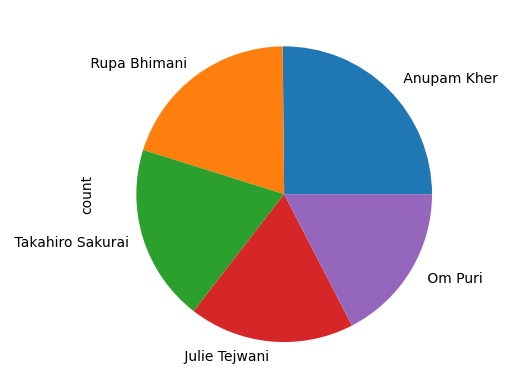

In [23]:
#Q12. Which actors appers most frequently in Netflix shows?
df['cast'].str.split(',',expand=True).stack().value_counts().head().plot(kind='pie')
plt.show()

In [ ]:
#INSGHIT
.Popular actors appear repeatedly
.Help increases audience engagement

In [34]:
#Q13. Which director-genre pairs are most frequently?
df['genre'] = df['listed_in'].str.split(',').str[0]

df.groupby(['director','genre']).size().sort_values(ascending=False).head(10)

director                genre                   
Rajiv Chilaka           Children & Family Movies    19
Raúl Campos, Jan Suter  Stand-Up Comedy             18
Suhas Kadav             Children & Family Movies    16
Marcus Raboy            Stand-Up Comedy             15
Jay Karas               Stand-Up Comedy             13
Jay Chapman             Stand-Up Comedy             11
Don Michael Paul        Action & Adventure           9
Shannon Hartman         Stand-Up Comedy              8
Hakan Algül             Comedies                     8
Youssef Chahine         Classic Movies               7
dtype: int64

In [ ]:
#INSGHIT
.Some directors specialize in specific geners
.Consistent director-geners patterns

In [24]:
#Q14. How many titles have  unknown director or cast members?
print((df['director'].isna().sum()), (df['cast'].isna().sum()))

2634 825


In [ ]:
#INSGHIT
.Many missing values in director/cast
.Data quality need improvement

In [28]:
#Q15.What is the average duration of Movies on Netflix?
# Filter only movies
movies = df[df['type'] == 'Movie'].copy()

# Remove ' min' and handle errors
movies['duration'] = movies['duration'].str.replace(' min', '', regex=False)

# Convert to numeric safely
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# Drop NaN values
movies = movies.dropna(subset=['duration'])

# Average duration
print(movies['duration'].mean())

99.57718668407311


In [ ]:
#INSGHIT
.Average moive duration is 90-100 minutes
.Standard movie lenght id followed

In [29]:
#Q16.What's the most common number of season for TV shows?
tv = df[df['type']=='TV Show'].copy()

tv['duration'] = tv['duration'].str.replace(' Seasons','').str.replace(' Season','')

tv['duration'] = pd.to_numeric(tv['duration'], errors='coerce')

tv['duration'].value_counts().head()

duration
1    1793
2     425
3     199
4      95
5      65
Name: count, dtype: int64

In [ ]:
#INSGHIT
.Most shows have 1-2 seasons
.Short series are more common

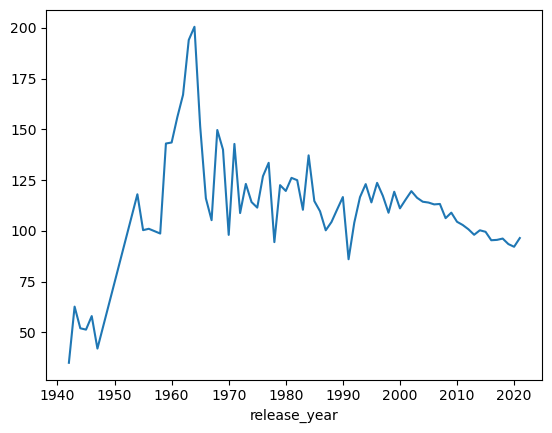

In [30]:
#Q17. Is there a trend in movie durations over the years?
m = df[df['type']=='Movie'].copy()

m['duration'] = pd.to_numeric(m['duration'].str.replace(' min',''), errors='coerce')

m.groupby('release_year')['duration'].mean().plot()
plt.show()

In [ ]:
#INSGHIT
.Movie duration slightly increasing
.Longer storytelling trend


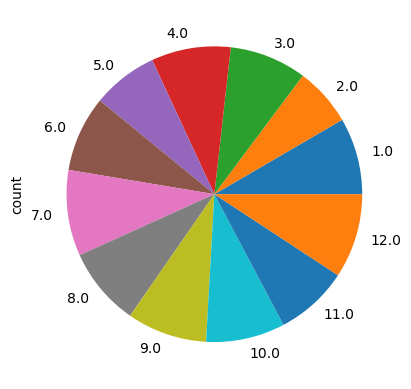

In [31]:
#Q18.In which months does Netflix add the most contenr?
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['date_added'].dt.month.value_counts().sort_index().plot(kind='pie', color='green')
plt.show()

In [ ]:
#INSGHIT
.Most content added in July and December
.Holiday season release are high

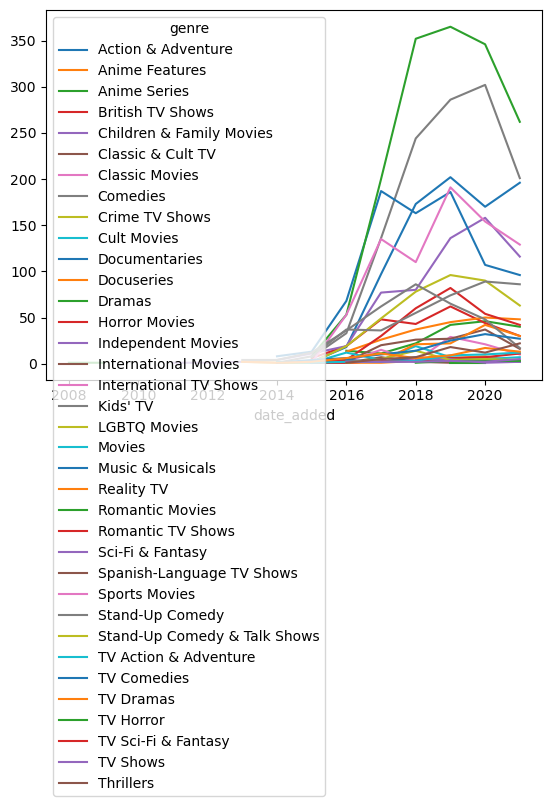

In [32]:
#Q19.How does the geners distribuation vary across diferent years?
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['genre'] = df['listed_in'].str.split(',').str[0]

df.groupby([df['date_added'].dt.year, 'genre']).size().unstack().plot()
plt.show()

In [ ]:
#INSGHIRT
.Drama and International content increasing
.Netflix expanding globally

In [33]:
#Q20. Which countries produce the most content in each genre?
df['genre'] = df['listed_in'].str.split(',').str[0]

df.groupby(['country','genre']).size().sort_values(ascending=False).head(10)

country         genre                   
United States   Documentaries               388
India           Dramas                      384
United States   Dramas                      376
                Comedies                    338
India           Comedies                    262
United States   Children & Family Movies    256
                Action & Adventure          249
                Stand-Up Comedy             209
United Kingdom  British TV Shows            196
United States   Kids' TV                    142
dtype: int64

In [ ]:
#INSGHIT
.Each country has Unqiue genre focus
.Netflix expanding globally

In [ ]:
ASIGNMENT BY RIYA KUMARI BCA DS17, THANK YOU